# Анализ и прогнозирование биохимической активности соединений

## Описание задачи

Данные содержат молекулярные дескрипторы и экспериментальные значения биохимической активности: IC50 (ингибирование), CC50 (цитотоксичность) и SI (индекс селективности). Задача — построить модели для прогнозирования трёх целевых переменных.

**Основные этапы:**

1. Анализ структуры данных и обработка пропусков
2. Исследование распределений целевых переменных
3. Корреляционный анализ признаков
4. Создание новых признаков
5. Сравнение моделей и подбор гиперпараметров
6. Прогнозирование на тестовых данных

Результат на Kaggle: 290.43069

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import HuberRegressor, Lasso, LinearRegression
from copy import deepcopy
import xgboost as xgb
import lightgbm as lgb
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore')

SEED=42

### Загрузка и первичный анализ данных

In [2]:
data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

data.head()


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [4]:
data.describe()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,...,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000
mean,375.000000,204.544021,577.426098,89.153313,10.860070,10.860070,0.180064,-0.971890,0.577938,29.588010,...,0.055925,0.013316,0.010652,0.001332,0.001332,0.054594,0.0,0.069241,0.182423,0.006658
std,216.939316,370.367937,641.515163,788.882198,3.347314,3.347314,0.169163,1.594491,0.214190,12.713195,...,0.272400,0.114699,0.102728,0.036491,0.036491,0.227337,0.0,0.254033,1.227468,0.081377
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.545455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,187.500000,13.222351,99.998894,1.500000,8.921032,8.921032,0.048473,-1.333831,0.442842,18.306020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,375.000000,44.069306,376.580899,4.000000,12.197500,12.197500,0.121372,-0.419485,0.636477,29.281250,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,562.500000,206.787402,877.508784,17.372463,13.214245,13.214245,0.290990,0.072488,0.742483,38.875000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,750.000000,4095.188563,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


### Анализ целевых переменных


In [5]:
data = data.rename(columns={
    'IC50, mM': 'IC50',
    'CC50, mM': 'CC50',
    'SI': 'SI'
})
target_cols = ['IC50', 'CC50', 'SI']
data.describe()

,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,...,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000
mean,375.000000,204.544021,577.426098,89.153313,10.860070,10.860070,0.180064,-0.971890,0.577938,29.588010,...,0.055925,0.013316,0.010652,0.001332,0.001332,0.054594,0.0,0.069241,0.182423,0.006658
std,216.939316,370.367937,641.515163,788.882198,3.347314,3.347314,0.169163,1.594491,0.214190,12.713195,...,0.272400,0.114699,0.102728,0.036491,0.036491,0.227337,0.0,0.254033,1.227468,0.081377
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.545455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,187.500000,13.222351,99.998894,1.500000,8.921032,8.921032,0.048473,-1.333831,0.442842,18.306020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,375.000000,44.069306,376.580899,4.000000,12.197500,12.197500,0.121372,-0.419485,0.636477,29.281250,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,562.500000,206.787402,877.508784,17.372463,13.214245,13.214245,0.290990,0.072488,0.742483,38.875000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,750.000000,4095.188563,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [6]:
target_cols = ['IC50', 'CC50', 'SI']
target_stats = {}


Анализ: Распределения original vs log(target)


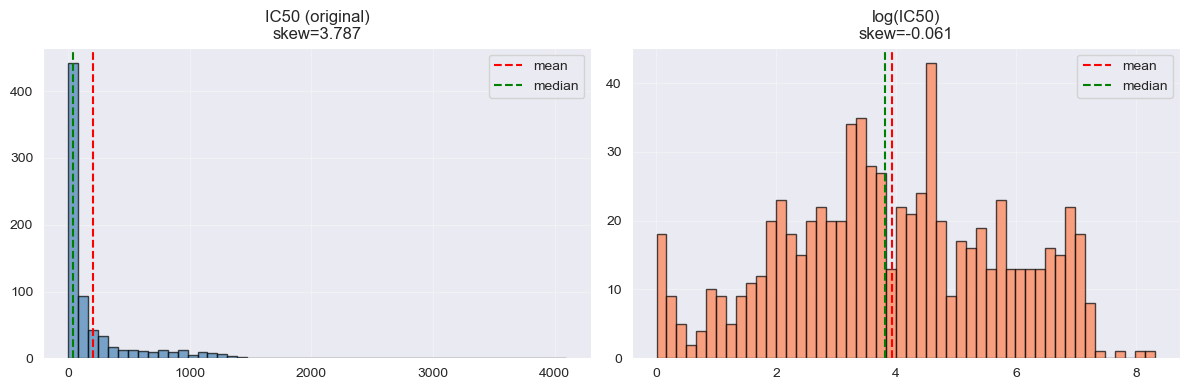


IC50:
  Original: skew=3.787, kurtosis=24.408
  Log:      skew=-0.061, kurtosis=-0.676


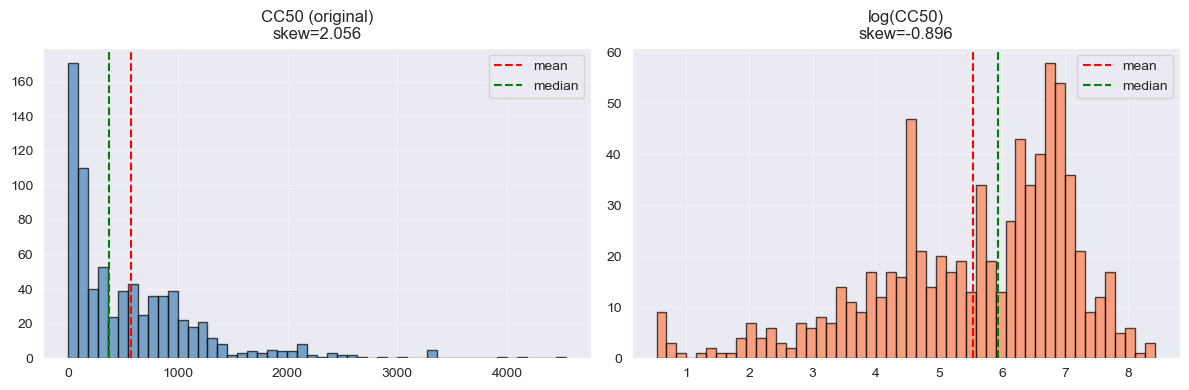


CC50:
  Original: skew=2.056, kurtosis=6.095
  Log:      skew=-0.896, kurtosis=0.477


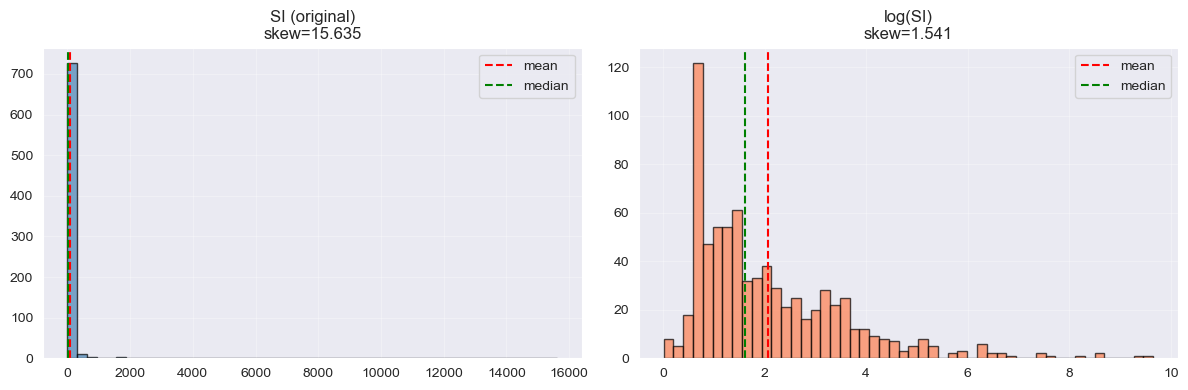


SI:
  Original: skew=15.635, kurtosis=271.600
  Log:      skew=1.541, kurtosis=3.147


In [7]:
print("Анализ: Распределения original vs log(target)")

for target in target_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(data[target], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title(f'{target} (original)\nskew={data[target].skew():.3f}')
    axes[0].axvline(data[target].mean(), color='red', linestyle='--', label='mean')
    axes[0].axvline(data[target].median(), color='green', linestyle='--', label='median')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    log_target = np.log1p(data[target])
    axes[1].hist(log_target, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_title(f'log({target})\nskew={log_target.skew():.3f}')
    axes[1].axvline(log_target.mean(), color='red', linestyle='--', label='mean')
    axes[1].axvline(log_target.median(), color='green', linestyle='--', label='median')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{target}:")
    print(f"  Original: skew={data[target].skew():.3f}, kurtosis={data[target].kurtosis():.3f}")
    print(f"  Log:      skew={log_target.skew():.3f}, kurtosis={log_target.kurtosis():.3f}")


Вывод: Целевые переменные имеют длинный правый хвост. Логарифмирование уменьшает асимметрию и может улучшить качество линейных моделей.



### Анализ пропусков

In [8]:
missing_train = data.isnull().sum()
missing_train_percent = (missing_train / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing_train_Count': missing_train,
    'Missing_train_Percent': missing_train_percent
}).sort_values('Missing_train_Percent', ascending=False)

missing_df[missing_df['Missing_train_Count'] > 0]

missing_test = test_data.isnull().sum()
missing_test_percent = (missing_test / len(test_data)) * 100
missing_df['Missing_test_Count'] = missing_test
missing_df['Missing_test_Percent'] = missing_test_percent

print("\nПропуски в обучающей выборке:")
missing_df[missing_df['Missing_test_Count'] > 0]


Пропуски в обучающей выборке:


,Missing_train_Count,Missing_train_Percent,Missing_test_Count,Missing_test_Percent
MinAbsPartialCharge,2,0.266312,1.0,0.4
BCUT2D_LOGPHI,2,0.266312,1.0,0.4
BCUT2D_MWHI,2,0.266312,1.0,0.4
MaxAbsPartialCharge,2,0.266312,1.0,0.4
MinPartialCharge,2,0.266312,1.0,0.4
MaxPartialCharge,2,0.266312,1.0,0.4
BCUT2D_MWLOW,2,0.266312,1.0,0.4
BCUT2D_CHGHI,2,0.266312,1.0,0.4
BCUT2D_CHGLO,2,0.266312,1.0,0.4
BCUT2D_LOGPLOW,2,0.266312,1.0,0.4


Объём пропусков незначителен, поэтому строки с пропусками не удаляются. В пайплайн включено **заполнение пропусков медианным значением** (`SimpleImputer(strategy='median')`), что позволяет сохранить все данные и избежать смещения оценок.

In [9]:
clean_data = data.fillna(data.median())

### Анализ распределений признаков

In [10]:
feature_types = {
    'Бинарные (0/1)': [],
    'Счётные (2-20 целых значений)': [],
    'Счётные (>20 целых значений)': [],
    'Непрерывные (float)': [],
    'Константные (одно значение)': []
}

for col in clean_data.columns:
    unique_vals = clean_data[col].nunique()
    min_val = clean_data[col].min()
    max_val = clean_data[col].max()

    is_integer = np.all(clean_data[col] == clean_data[col].astype(int))

    if unique_vals == 1:
        feature_types['Константные (одно значение)'].append(col)
    elif is_integer:
        if unique_vals == 2:
            feature_types['Бинарные (0/1)'].append(col)
        elif unique_vals <= 20:
            feature_types['Счётные (2-20 целых значений)'].append(col)
        else:
            feature_types['Счётные (>20 целых значений)'].append(col)
    else:
        feature_types['Непрерывные (float)'].append(col)

print("\nРаспределение признаков по типам:")
for type_name, features in feature_types.items():
    print(f"  {type_name:35}: {len(features):4} шт. ({len(features)/len(clean_data.columns)*100:.1f}%)")



Распределение признаков по типам:
  Бинарные (0/1)                     :   31 шт. (14.5%)
  Счётные (2-20 целых значений)      :   51 шт. (23.8%)
  Счётные (>20 целых значений)       :    7 шт. (3.3%)
  Непрерывные (float)                :  107 шт. (50.0%)
  Константные (одно значение)        :   18 шт. (8.4%)


В ходе анализа выявлено, что признаки имеют различную природу:

- **Константные признаки** (18 шт.) не несут информации и будут удалены на этапе предобработки
- **Бинарные и счётные признаки** не требуют масштабирования и обрезания выбросов
- **Непрерывные признаки** составляют половину всех признаков — для них применяется стандартизация (если требуется) и логарифмирование скошенных распределений

Такой подход позволяет корректно обработать каждый тип признаков без потери информации и искажения данных.

### Корреляционный анализ

In [11]:
target_cols = ['IC50', 'CC50', 'SI']
corr_matrix = clean_data[target_cols].corr()
corr_matrix

,IC50,CC50,SI
IC50,1.000000,0.470444,-0.060518
CC50,0.470444,1.000000,-0.005702
SI,-0.060518,-0.005702,1.000000


Целевые переменные IC50, CC50 и SI слабо коррелируют между собой.

Следовательно, зависимости между признаками и каждой из целевых переменных имеют различную структуру.
Единая многоцелевая модель не сможет одновременно качественно аппроксимировать все три целевые переменные.

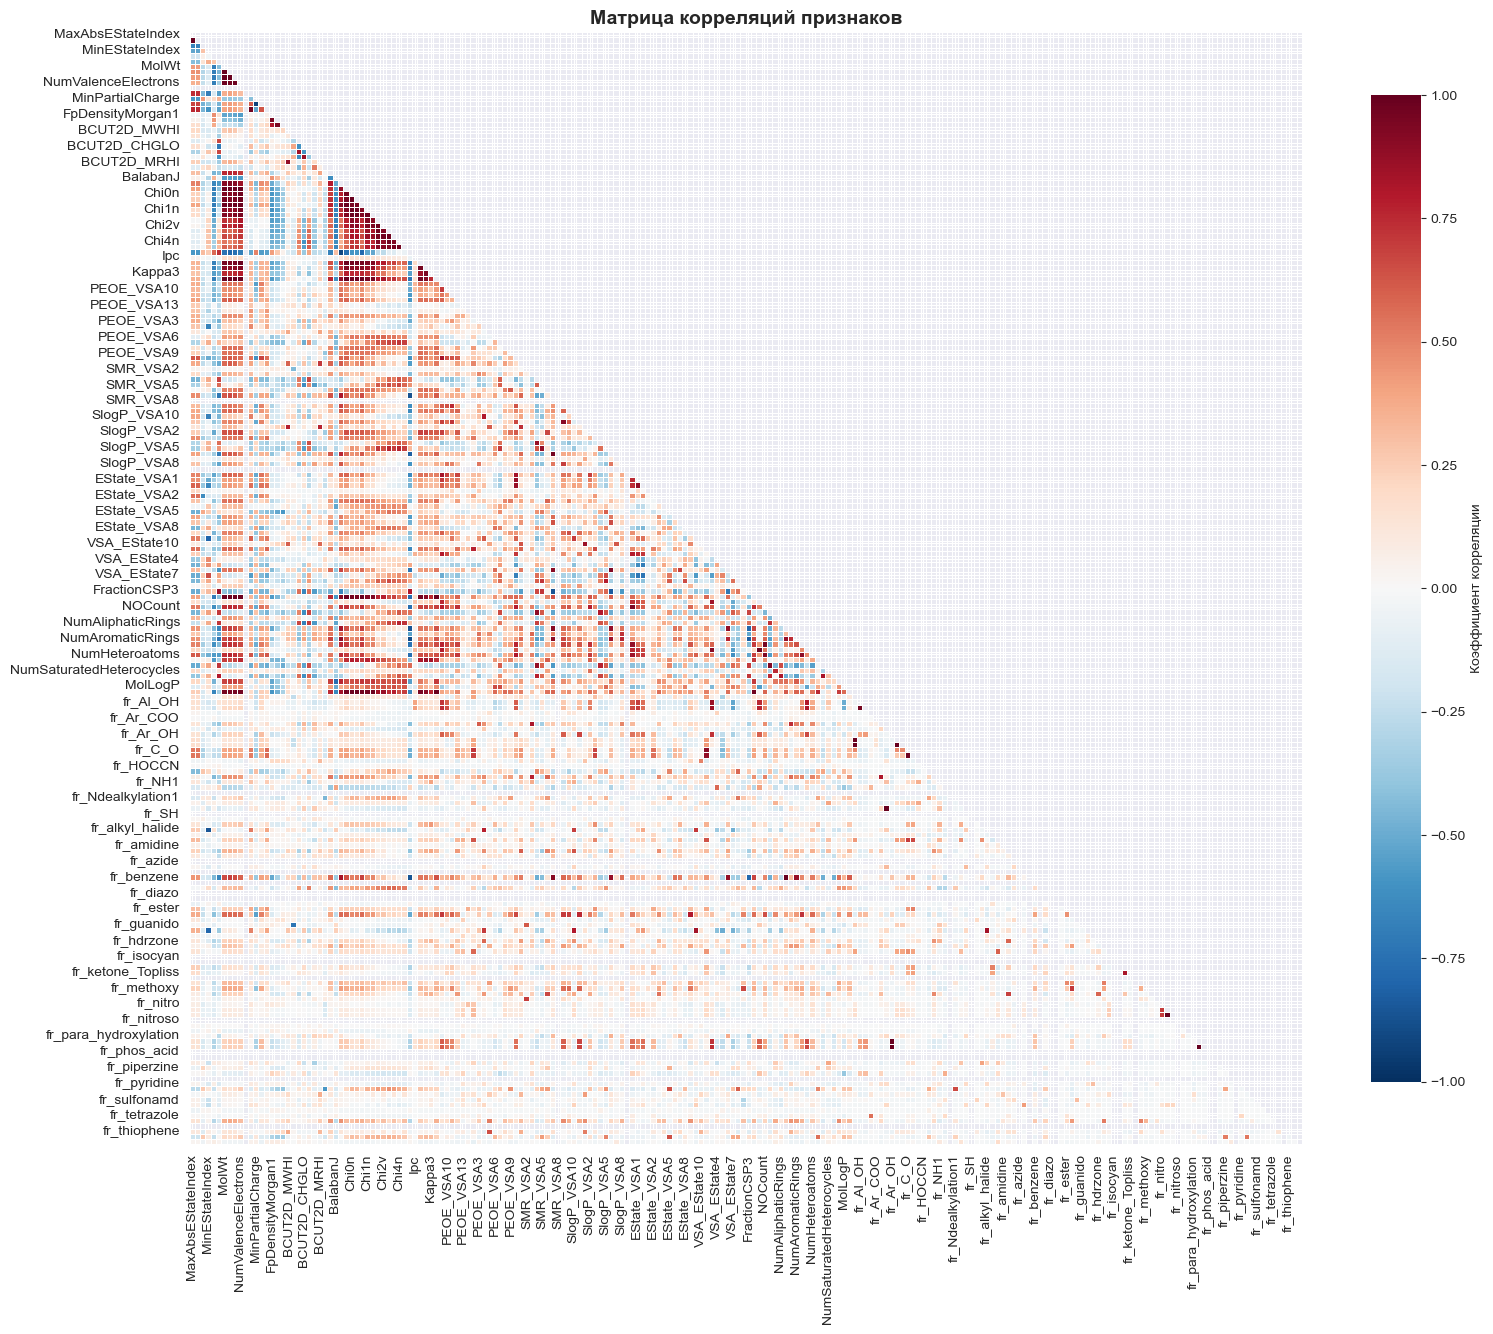

In [12]:
feature_cols = [col for col in clean_data.columns if col not in target_cols + ['index']]
feature_data = clean_data[feature_cols]

corr_matrix = clean_data[feature_cols].corr()


plt.figure(figsize=(16, 14))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
            vmin=-1, vmax=1)

plt.title('Матрица корреляций признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Вывод: Есть признаки с высокой линейной корреляцией. В пайплайн добавлено удаление признаков с корреляцией > 0.98.

### Создание признаков

#### Анализ скошенных признаков


Найдено 7 сильно скошенных признаков:
['MinAbsEStateIndex', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_MRHI', 'Chi3n', 'Ipc', 'Kappa3']


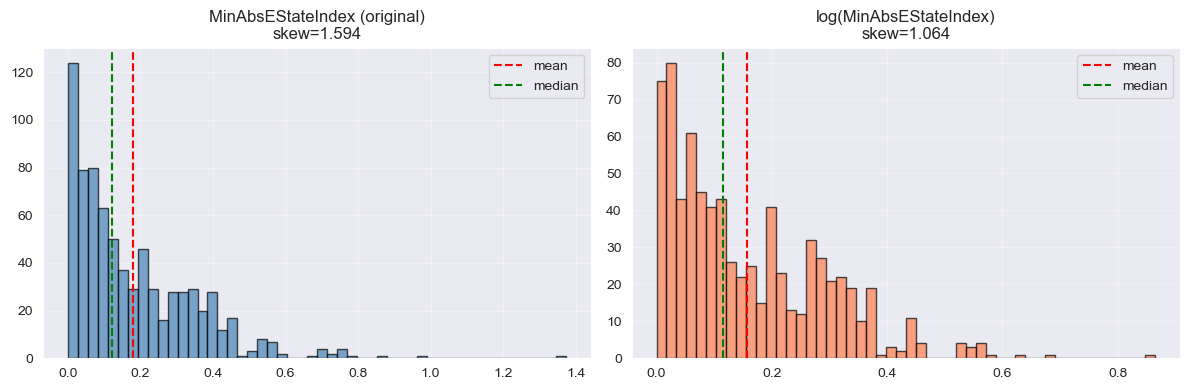


MinAbsEStateIndex:
  Original: skew=1.594, min=0.0000, max=1.3746
  Log:      skew=1.064


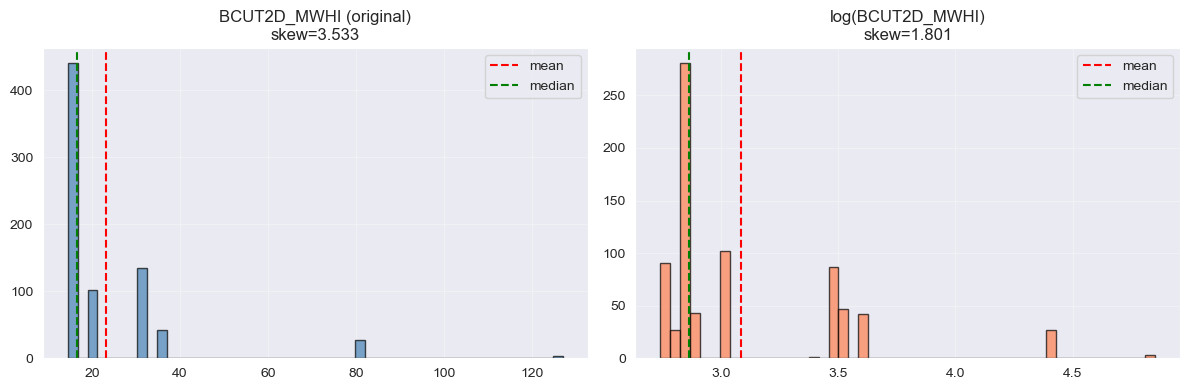


BCUT2D_MWHI:
  Original: skew=3.533, min=14.5139, max=126.9127
  Log:      skew=1.801


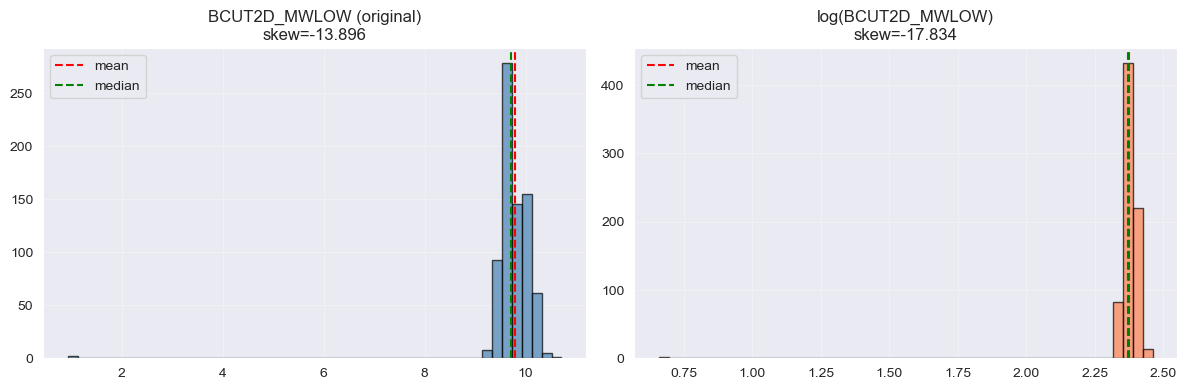


BCUT2D_MWLOW:
  Original: skew=-13.896, min=0.9313, max=10.7089
  Log:      skew=-17.834


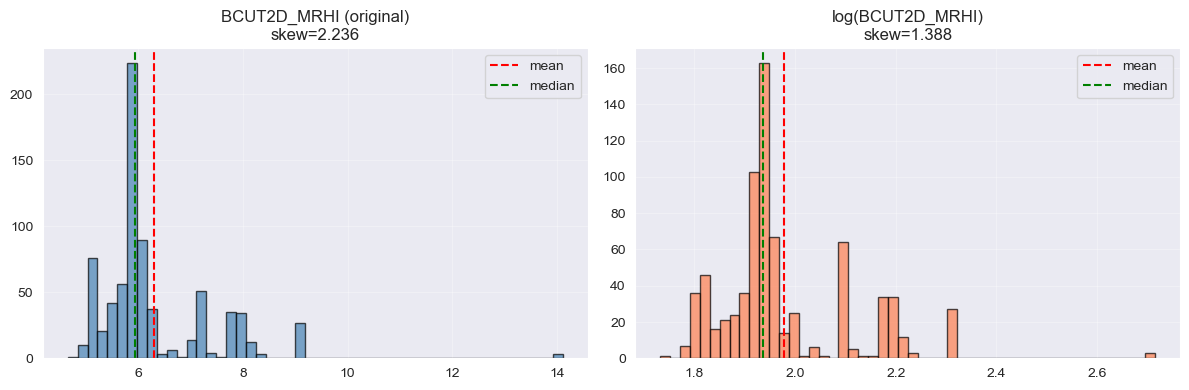


BCUT2D_MRHI:
  Original: skew=2.236, min=4.6521, max=14.1120
  Log:      skew=1.388


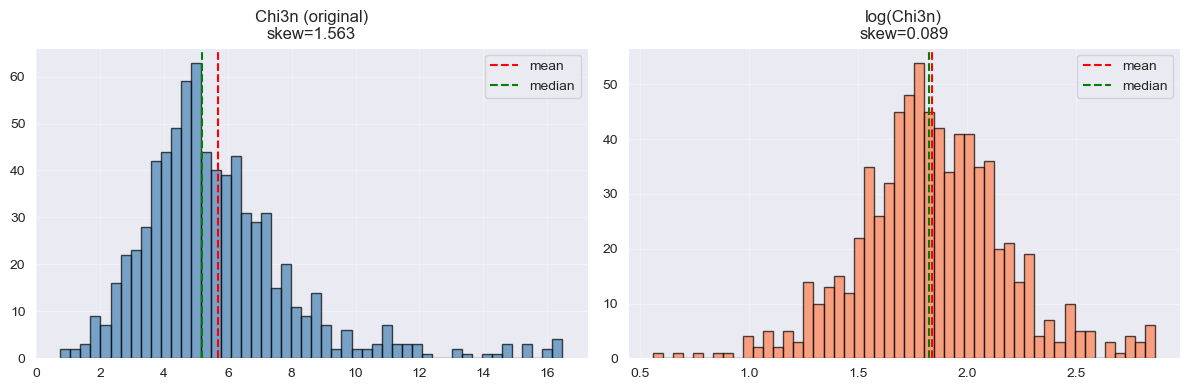


Chi3n:
  Original: skew=1.563, min=0.7500, max=16.4766
  Log:      skew=0.089


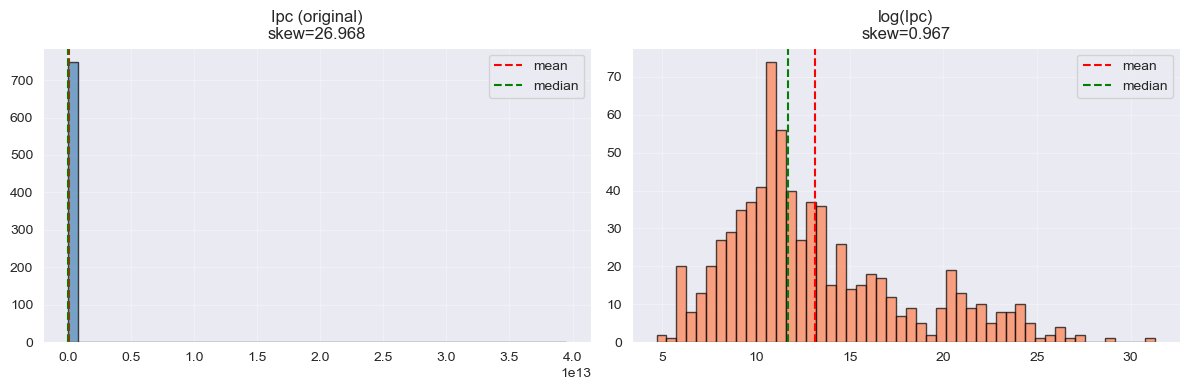


Ipc:
  Original: skew=26.968, min=107.1072, max=39517808516075.6172
  Log:      skew=0.967


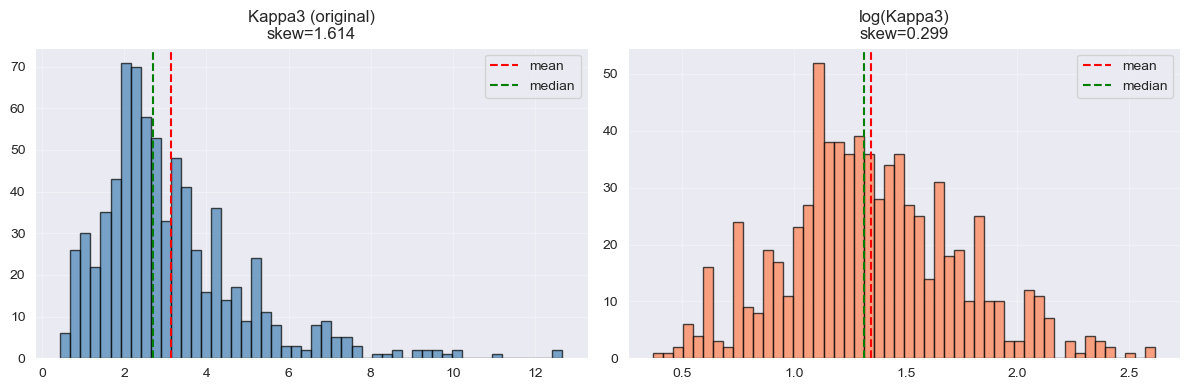


Kappa3:
  Original: skew=1.614, min=0.4450, max=12.6663
  Log:      skew=0.299


In [13]:
skewed_features = [col for col in feature_data.columns if feature_data[col].min() > 0 and abs(feature_data[col].skew()) > 1.5]

print(f"\nНайдено {len(skewed_features)} сильно скошенных признаков:")
print(skewed_features)

for feature in skewed_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(feature_data[feature], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title(f'{feature} (original)\nskew={feature_data[feature].skew():.3f}')
    axes[0].axvline(feature_data[feature].mean(), color='red', linestyle='--', label='mean')
    axes[0].axvline(feature_data[feature].median(), color='green', linestyle='--', label='median')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    log_feature = np.log1p(feature_data[feature])
    axes[1].hist(log_feature, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_title(f'log({feature})\nskew={log_feature.skew():.3f}')
    axes[1].axvline(log_feature.mean(), color='red', linestyle='--', label='mean')
    axes[1].axvline(log_feature.median(), color='green', linestyle='--', label='median')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{feature}:")
    print(f"  Original: skew={feature_data[feature].skew():.3f}, min={feature_data[feature].min():.4f}, max={feature_data[feature].max():.4f}")
    print(f"  Log:      skew={log_feature.skew():.3f}")


7 признаков сильно скошены. Хотя визуально разница после логорифмирования видна не у всех признаков, включу в пайплайн стадию логорифмирования признаков. Если skew станет ближе к 0 после преобразования, то заменю исходный признак на его логорифм.

#### Создание дополнительных признаков

Проанализирую, какие признаки коррелируют с целевыми переменными.

In [14]:

def analyze_feature_importance(X, y, feature_names, top_k=20):
    rf = RandomForestRegressor(n_estimators=50, random_state=SEED, n_jobs=-1, max_depth=10)
    rf.fit(X, y)

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    return importance_df


feature_cols_used = feature_data.columns.tolist()

print("\nТоп-10 признаков по важности для каждого таргета (ИНФОРМАЦИЯ только):")
for target in target_cols:
    print(f"\n{target}:")
    imp_df = analyze_feature_importance(feature_data, clean_data[target].values, feature_cols_used, top_k=10)
    print(imp_df.head(10)[['feature', 'importance']].to_string(index=False))



Топ-10 признаков по важности для каждого таргета (ИНФОРМАЦИЯ только):

IC50:
         feature  importance
    BCUT2D_MWLOW    0.140740
     VSA_EState4    0.068014
           Chi1v    0.060841
FpDensityMorgan3    0.052675
           Chi4v    0.030815
           Chi2v    0.023055
    BCUT2D_MRLOW    0.020508
     EState_VSA5    0.018957
           MolMR    0.017809
             qed    0.016798

CC50:
         feature  importance
       LabuteASA    0.094341
            Chi1    0.071471
    BCUT2D_MWLOW    0.049873
          Kappa2    0.039836
FpDensityMorgan1    0.031843
          Kappa3    0.031787
           Chi1n    0.024504
    BCUT2D_MRLOW    0.021597
FpDensityMorgan2    0.020350
     BCUT2D_MWHI    0.020207

SI:
            feature  importance
        VSA_EState6    0.588308
        VSA_EState9    0.071948
   MaxPartialCharge    0.030991
MinAbsPartialCharge    0.019825
          PEOE_VSA9    0.016857
MaxAbsPartialCharge    0.016444
             fr_NH0    0.013392
                

### Инжиниринг признаков

Поскольку корреляционный анализ не выявил признаков, сильно связанных с целевыми переменными (максимальная корреляция с IC50/CC50/SI не превышает 0.25), добавление новых признаков путём простых комбинаций существующих (суммы, разности, отношения) приведёт лишь к дублированию информации и не даст прироста качества.

Вместо этого был применён подход, основанный на **физико-химическом смысле** дескрипторов. На основе топ-признаков, выделенных RandomForest, созданы новые характеристики, отражающие:

- **Плотность упаковки молекулы** (`density_surface`) — масса / площадь поверхности
- **Гидрофобность на единицу площади** (`hydrophobicity_density`)
- **Степень разветвлённости** (`branching_index`) — отношение валентного индекса к индексу связности
- **Компактность и цикличность** (`compactness_ratio`, `cyclicity`) — на основе Kappa-индексов
- **Гибкость молекулы** (`flexibility_ratio`) — вращаемые связи / кольца

In [15]:
def add_chemically_meaningful_features(X):
    X = X.copy()

    if 'LabuteASA' in X.columns and 'MolWt' in X.columns:
        X['density_surface'] = X['MolWt'] / (X['LabuteASA'] + 0.1)

    if 'MolLogP' in X.columns and 'LabuteASA' in X.columns:
        X['hydrophobicity_density'] = X['MolLogP'] / (X['LabuteASA'] + 0.1)

    if 'Chi1' in X.columns and 'Chi1v' in X.columns:
        X['branching_index'] = X['Chi1v'] / (X['Chi1'] + 0.1)

    if all(c in X.columns for c in ['Kappa1', 'Kappa2', 'Kappa3']):
        X['compactness_ratio'] = (X['Kappa2'] + X['Kappa3']) / (X['Kappa1'] + 0.1)
        X['cyclicity'] = X['Kappa3'] / (X['Kappa2'] + 0.1)

    if 'NumAromaticRings' in X.columns and 'NumSaturatedRings' in X.columns:
        X['aromaticity_index'] = X['NumAromaticRings'] / (X['NumAromaticRings'] + X['NumSaturatedRings'] + 0.1)

    if all(c in X.columns for c in ['BCUT2D_MWLOW', 'BCUT2D_MRLOW', 'BCUT2D_CHGLO']):
        X['charge_to_mass'] = X['BCUT2D_CHGLO'] / (X['BCUT2D_MWLOW'] + 0.1)
        X['bcut_spread'] = X['BCUT2D_MWLOW'] - X['BCUT2D_MRLOW']

    if 'TPSA' in X.columns and 'LabuteASA' in X.columns:
        X['polar_surface_ratio'] = X['TPSA'] / (X['LabuteASA'] + 0.1)

    if 'NumRotatableBonds' in X.columns and 'RingCount' in X.columns:
        X['flexibility_ratio'] = X['NumRotatableBonds'] / (X['RingCount'] + 1)
        X['rigidity'] = X['RingCount'] / (X['NumRotatableBonds'] + 1)

    if 'BCUT2D_MWLOW' in X.columns and 'VSA_EState4' in X.columns:
        X['ic50_interaction'] = X['BCUT2D_MWLOW'] * X['VSA_EState4']

    if 'LabuteASA' in X.columns and 'Chi1' in X.columns:
        X['cc50_interaction'] = X['LabuteASA'] * X['Chi1']

    if 'VSA_EState6' in X.columns and 'MinAbsPartialCharge' in X.columns:
        X['si_interaction'] = X['VSA_EState6'] * X['MinAbsPartialCharge']

    if 'FractionCsp3' in X.columns:
        X['saturation'] = X['FractionCsp3']  
        X['unsaturation'] = 1 - X['FractionCsp3']

    if 'NumHDonors' in X.columns and 'NumHAcceptors' in X.columns:
        X['donor_acceptor_ratio'] = X['NumHDonors'] / (X['NumHAcceptors'] + 0.1)

    return X

X_engineered = add_chemically_meaningful_features(feature_data)
print(f"Добавлены химически осмысленные признаки")
print(f"  Было: {feature_data.shape[1]} → Стало: {X_engineered.shape[1]}")

new_cols = [col for col in X_engineered.columns if col not in feature_data.columns]
print(f"\nНовые химические признаки ({len(new_cols)} шт.):")
for feat in new_cols:
    print(f"  - {feat}")

Добавлены химически осмысленные признаки
  Было: 210 → Стало: 225

Новые химические признаки (15 шт.):
  - density_surface
  - hydrophobicity_density
  - branching_index
  - compactness_ratio
  - cyclicity
  - aromaticity_index
  - charge_to_mass
  - bcut_spread
  - polar_surface_ratio
  - flexibility_ratio
  - rigidity
  - ic50_interaction
  - cc50_interaction
  - si_interaction
  - donor_acceptor_ratio


**Отбор новых признаков** проводится по двум критериям:
1. Максимальная корреляция с исходными признаками < 0.8 (чтобы не дублировать информацию)
2. Наличие корреляции с целевой переменной (|r| > 0.1 хотя бы для одной цели)


In [16]:
all_new_features = [col for col in X_engineered.columns if col not in feature_data.columns]

results = []

for new_f in all_new_features:
    base_corr = []
    for base_f in feature_data.columns:
        if base_f in X_engineered.columns:
            corr_val = abs(X_engineered[new_f].corr(X_engineered[base_f]))
            if not np.isnan(corr_val):
                base_corr.append(corr_val)

    max_corr_base = max(base_corr) if base_corr else 0

    corr_ic50 = X_engineered[new_f].corr(clean_data['IC50']) if 'IC50' in clean_data.columns else 0
    corr_cc50 = X_engineered[new_f].corr(clean_data['CC50']) if 'CC50' in clean_data.columns else 0
    corr_si = X_engineered[new_f].corr(clean_data['SI']) if 'SI' in clean_data.columns else 0

    if max_corr_base < 0.8 and (abs(corr_ic50) > 0.1 or abs(corr_cc50) > 0.1 or abs(corr_si) > 0.1):
        results.append({
            'Признак': new_f,
            'Макс.корр. с исходными': max_corr_base,
            'Корр. IC50': corr_ic50,
            'Корр. CC50': corr_cc50,
            'Корр. SI': corr_si,
            'Статус': 'ДОБАВИТЬ'
        })
    else:
        reason = []
        if max_corr_base >= 0.8:
            reason.append(f"дублирует исходные (корр={max_corr_base:.3f})")
        if abs(corr_ic50) <= 0.1 and abs(corr_cc50) <= 0.1 and abs(corr_si) <= 0.1:
            reason.append("слабая связь с целевыми")
        results.append({
            'Признак': new_f,
            'Макс.корр. с исходными': max_corr_base,
            'Корр. IC50': corr_ic50,
            'Корр. CC50': corr_cc50,
            'Корр. SI': corr_si,
            'Статус': f'ИСКЛЮЧИТЬ ({", ".join(reason)})'
        })

results_df = pd.DataFrame(results)
selected = results_df[results_df['Статус'].str.contains('ДОБАВИТЬ')].copy()

selected['Макс.корр.'] = selected['Макс.корр. с исходными'].round(4)
selected['IC50'] = selected['Корр. IC50'].round(4)
selected['CC50'] = selected['Корр. CC50'].round(4)
selected['SI'] = selected['Корр. SI'].round(4)

selected[['Признак', 'Макс.корр.', 'IC50', 'CC50', 'SI']]


,Признак,Макс.корр.,IC50,CC50,SI
0,density_surface,0.7086,0.1643,-0.0374,-0.0100
1,hydrophobicity_density,0.7745,-0.1265,-0.0786,-0.0827
2,branching_index,0.7875,-0.1374,0.0413,0.0088
3,compactness_ratio,0.7885,-0.0679,-0.2468,0.1171
4,cyclicity,0.5840,-0.0027,-0.1784,0.1024
9,flexibility_ratio,0.7985,-0.1230,-0.1374,0.2031


В результате отобрано **6 новых признаков**, которые могут улучшить качество моделей, не внося избыточности.

Проанализирую вариативность признаков.

In [17]:
def analyze_variance_features(X, threshold=0.001):
    selector = VarianceThreshold(threshold=threshold)
    X_selected = selector.fit_transform(X)
    selected_features = X.columns[selector.get_support()].tolist()
    removed_features = X.columns[~selector.get_support()].tolist()
    return X_selected, selected_features, removed_features


X_selected, selected_features, removed_variance = analyze_variance_features(X_engineered, threshold=0.01)
print(f"Информация: Признаков с низкой дисперсией: {len(removed_variance)}")
if removed_variance:
    print(f"Примеры: {removed_variance[:5]}")


Информация: Признаков с низкой дисперсией: 35
Примеры: ['NumRadicalElectrons', 'MinPartialCharge', 'MaxAbsPartialCharge', 'SMR_VSA8', 'SlogP_VSA9']


Поскольку выявлены такие признаки, данный этап добавлю в итоговый пайплайн.

## Пайплайн предобработки данных

Создам единый пайплайн, объединяющий все этапы предобработки данных. Такой подход обеспечивает:

1. **Централизованное управление гиперпараметрами** — настройки каждого этапа можно менять в одном месте;
2. **Отсутствие утечки данных** — все трансформации (медиана для заполнения пропусков, квантили для обрезания выбросов и т.д.) вычисляются только на обучающей выборке и затем применяются к тестовой;
3. **Идентичность преобразований** — гарантируется, что к обучающей и тестовой выборкам применяются одни и те же трансформации;
4. **Удобство экспериментов** — можно легко добавлять, удалять или заменять этапы обработки.

Добавление новых отобранных ранее признаков:

In [18]:
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        self.columns_ = X.columns.tolist()
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=self.columns_)
        X = X.copy()

        if 'LabuteASA' in X.columns and 'MolWt' in X.columns:
            X['density_surface'] = X['MolWt'] / (X['LabuteASA'] + 0.1)

        if 'MolLogP' in X.columns and 'LabuteASA' in X.columns:
            X['hydrophobicity_density'] = X['MolLogP'] / (X['LabuteASA'] + 0.1)

        if 'Chi1' in X.columns and 'Chi1v' in X.columns:
            X['branching_index'] = X['Chi1v'] / (X['Chi1'] + 0.1)

        if all(c in X.columns for c in ['Kappa1', 'Kappa2', 'Kappa3']):
            X['compactness_ratio'] = (X['Kappa2'] + X['Kappa3']) / (X['Kappa1'] + 0.1)
            X['cyclicity'] = X['Kappa3'] / (X['Kappa2'] + 0.1)

        if 'NumRotatableBonds' in X.columns and 'RingCount' in X.columns:
            X['flexibility_ratio'] = X['NumRotatableBonds'] / (X['RingCount'] + 1)

        return X


Добавляю обработку признаков с учетом их типа, сохраняя информацию о типах для последующих этапов.

**Определяемые типы признаков:**

| Тип | Условие | Действие |
|-----|---------|----------|
| **Константные** | `nunique() == 1` | Удаляются |
| **Бинарные** | целые, 2 значения, только {0, 1} | Не масштабируются, не обрезаются |
| **Счётные** | целые, `nunique() <= 20` | Не масштабируются, не обрезаются |
| **Непрерывные** | все остальные | Логарифмируются (при `skew > threshold`), масштабируются |

**Параметры:**
- `skew_threshold` (default=2) — порог асимметрии для логарифмирования
- `log_transform` (default=True) — применять ли логарифмирование
- `scale_continuous` (default=True) — масштабировать ли непрерывные признаки

**Информация для последующих этапов:**
- `X.attrs['feature_types']` — словарь {признак: тип}
- `X.attrs['binary_features']` — список бинарных признаков
- `X.attrs['count_features']` — список счётных признаков
- `X.attrs['continuous_features']` — список непрерывных признаков

In [19]:
class AutoTypeTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, skew_threshold=2, log_transform=True):
        self.skew_threshold = skew_threshold
        self.log_transform = log_transform

        self.constant_features_ = []
        self.binary_features_ = []
        self.count_features_ = []
        self.continuous_features_ = []
        self.log_features_ = []
        self.scaler_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        for col in X.columns:
            unique_vals = X[col].nunique()
            min_val = X[col].min()
            is_integer = np.all(X[col] == X[col].astype(int))

            if unique_vals == 1:
                self.constant_features_.append(col)
            elif is_integer and unique_vals == 2 and set(X[col].unique()) <= {0, 1}:
                self.binary_features_.append(col)
            elif is_integer and unique_vals <= 20:
                self.count_features_.append(col)
            else:
                self.continuous_features_.append(col)

        self.all_features_ = X.columns.tolist()
        self.feature_types_ = {}
        for col in self.binary_features_:
            self.feature_types_[col] = 'binary'
        for col in self.count_features_:
            self.feature_types_[col] = 'count'
        for col in self.continuous_features_:
            self.feature_types_[col] = 'continuous'

        return self

    def transform(self, X):
        X = pd.DataFrame(X)

        X = X.drop(columns=self.constant_features_, errors='ignore')

        X.attrs['feature_types'] = self.feature_types_
        X.attrs['binary_features'] = self.binary_features_
        X.attrs['count_features'] = self.count_features_
        X.attrs['continuous_features'] = self.continuous_features_

        return X


Логарифмирование сильно скошенных непрерывных признаков (skew > threshold) с положительными значениями, если это уменьшает асимметрию:

In [20]:
class SelectiveLogTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, skew_threshold=1):
        self.skew_threshold = skew_threshold
        self.log_features_ = None
        self.columns_ = None

    def fit(self, X, y=None):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        self.columns_ = X.columns.tolist()
        self.log_features_ = []

        for col in X.columns:
            if X[col].nunique() < 3:
                continue

            if X[col].min() <= 0:
                continue

            original_skew = abs(X[col].skew())

            if original_skew > self.skew_threshold:
                log_skew = abs(np.log1p(X[col]).skew())

                if log_skew < original_skew:
                    self.log_features_.append(col)

        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=self.columns_)

        X = X.copy()

        for col in self.log_features_:
            if col in X.columns:
                X[col] = np.log1p(X[col])

        return X

Удаление выбросов по квантилям у непрерывных признаков.

In [21]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, method='quantile', low=0.005, high=0.995, multiplier=1.5, use_robust_scaler=False):
        self.method = method
        self.low = low
        self.high = high
        self.multiplier = multiplier
        self.use_robust_scaler = use_robust_scaler

        self.low_q_ = None
        self.high_q_ = None
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        self.continuous_features_ = None
        self.robust_scaler_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        if hasattr(X, 'attrs') and 'continuous_features' in X.attrs:
            self.continuous_features_ = X.attrs['continuous_features']
        else:
            self.continuous_features_ = X.select_dtypes(include=[np.number]).columns.tolist()
            self.continuous_features_ = [c for c in self.continuous_features_
                                         if X[c].nunique() > 20]

        if self.method == 'quantile':
            self.low_q_ = X[self.continuous_features_].quantile(self.low)
            self.high_q_ = X[self.continuous_features_].quantile(self.high)

        elif self.method == 'iqr':
            self.lower_bounds_ = {}
            self.upper_bounds_ = {}
            for col in self.continuous_features_:
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                self.lower_bounds_[col] = Q1 - self.multiplier * IQR
                self.upper_bounds_[col] = Q3 + self.multiplier * IQR

        elif self.method == 'robust':
            self.robust_scaler_ = RobustScaler()
            self.robust_scaler_.fit(X[self.continuous_features_])

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        if self.method == 'quantile':
            for col in self.continuous_features_:
                if col in X.columns:
                    X[col] = X[col].clip(self.low_q_[col], self.high_q_[col])

        elif self.method == 'iqr':
            for col in self.continuous_features_:
                if col in X.columns:
                    X[col] = X[col].clip(self.lower_bounds_[col], self.upper_bounds_[col])

        elif self.method == 'robust':
            if self.robust_scaler_ is not None:
                X[self.continuous_features_] = self.robust_scaler_.transform(X[self.continuous_features_])

        return X

Удаление признаков с низкой дисперсией. Бинарные признаки пропускает.

In [22]:
class SmartVarianceThreshold(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold = threshold
        self.keep_columns_ = None
        self.binary_features_ = []
        self.count_features_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        if hasattr(X, 'attrs') and 'binary_features' in X.attrs:
            self.binary_features_ = X.attrs['binary_features']
        if hasattr(X, 'attrs') and 'count_features' in X.attrs:
            self.count_features_ = X.attrs['count_features']

        always_keep = [c for c in self.binary_features_ + self.count_features_ if c in X.columns]

        other_features = [c for c in X.columns if c not in always_keep]

        if other_features:
            from sklearn.feature_selection import VarianceThreshold
            selector = VarianceThreshold(threshold=self.threshold)
            selector.fit(X[other_features])
            selected_other = [other_features[i] for i in np.where(selector.get_support())[0]]
        else:
            selected_other = []

        self.keep_columns_ = always_keep + selected_other
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.keep_columns_]


Удаляет высококоррелированные признаки (|r| > 0.98). Это необходимо для:
- устранения мультиколлинеарности (важно для линейных моделей);
- ускорения обучения моделей;
- повышения интерпретируемости результатов.

Для нелинейных моделей может быть исключен из пайплайна.

In [23]:
class CorrelationFilter(
    BaseEstimator,
    TransformerMixin
):

    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):

        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        self.columns_ = X.columns.tolist()

        corr_matrix = X.corr().abs()

        upper = corr_matrix.where(
            np.triu(
                np.ones(corr_matrix.shape),
                k=1
            ).astype(bool)
        )

        to_drop = [
            c for c in upper.columns
            if any(
                upper[c] > self.threshold
            )
        ]

        self.keep_columns_ = [
            c for c in X.columns
            if c not in to_drop
        ]

        return self

    def transform(self, X):

        if isinstance(X, np.ndarray):
            X = pd.DataFrame(
                X,
                columns=self.columns_
            )

        return X[self.keep_columns_]

## Подбор моделей и гиперпараметров

Для каждой целевой переменной подбирается оптимальная модель. Для IC50 и CC50 предпочтение отдаётся **нелинейным моделям** (XGBoost, LightGBM, CatBoost, RandomForest), так как зависимости имеют сложную структуру. Для SI дополнительно рассматриваются **линейные модели** (Ridge, Lasso, Huber и др.).

**Сетки гиперпараметров** настроены индивидуально для каждой модели с учётом её особенностей. Подбор выполняется через `RandomizedSearchCV` (15 итераций, 5-фолдовая CV). Качество оценивается по **NRMSE** — нормированному RMSE (RMSE / диапазон целевой переменной), что позволяет корректно сравнивать модели.

**Этапы предобработки** настроены индивидуально для каждой целевой переменной.

In [24]:
def get_pipeline_for_target(target_name, model_name):
    if target_name in ['IC50']:
        preprocess_steps = [
            ('imputer', SimpleImputer(strategy='median')),
            ('feature_engineering', FeatureEngineeringTransformer()),
            ('auto_type', AutoTypeTransformer(skew_threshold=2)),
            ('outliers', OutlierHandler('quantile', 0.005, 0.995)),
            ('variance', SmartVarianceThreshold(0.01)),
            ('corr_filter', CorrelationFilter(0.98)),
        ]
    elif target_name in ['CC50']:
        preprocess_steps = [
            ('imputer', SimpleImputer(strategy='median')),
            ('feature_engineering', FeatureEngineeringTransformer()),
            ('auto_type', AutoTypeTransformer(skew_threshold=2)),
            ('outliers', OutlierHandler('quantile', 0.005, 0.995)),
            ('variance', SmartVarianceThreshold(0.001)),
            ('corr_filter', CorrelationFilter(0.98)),
        ]

    elif target_name == 'SI':
        preprocess_steps = [
        ('auto_type', AutoTypeTransformer(skew_threshold=2)),
        ('outliers', OutlierHandler(method='iqr', multiplier=1.5)),
        ('scaler', StandardScaler()),
        ]

    else:
        raise ValueError(f"Unknown target: {target_name}")

    model_config = {
        'xgb': xgb.XGBRegressor(random_state=SEED, verbosity=0, n_jobs=-1),
        'lgb': lgb.LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=-1),
        'ridge': Ridge(random_state=SEED),
        'lasso': Lasso(random_state=SEED, max_iter=10000),
        'linear': LinearRegression(),
        'huber': HuberRegressor(max_iter=1000),
        'rf': RandomForestRegressor(random_state=SEED, n_jobs=-1),
    }

    model = model_config.get(model_name)
    if model is None:
        raise ValueError(f"Unknown model: {model_name}")

    params_grids = {
        'xgb': {
            'model__n_estimators': [300, 500, 800],
            'model__max_depth': [3, 4, 5, 6, 8],
            'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        },
        'lgb': {
            'model__n_estimators': [200, 300, 500],
            'model__max_depth': [5, 6, 7, 8],
            'model__learning_rate': [0.01, 0.05, 0.1],
        },
        'ridge': {
            'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
        },
        'lasso': {
            'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
        },
        'linear': {
            'model__fit_intercept': [True, False]
        },
        'huber': {
            'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1],
            'model__epsilon': [1.1, 1.35, 1.5, 2.0]
        },
        'rf': {
            'model__n_estimators': [200, 300, 500],
            'model__max_depth': [10, 15, 20, None]
        }
    }

    params = params_grids.get(model_name, {})

    preprocess_steps.append(('model', model))
    pipeline = Pipeline(preprocess_steps)

    return pipeline, params

In [25]:
feature_cols = [
    col for col in data.columns
    if col not in ['IC50', 'CC50', 'SI', 'id', 'index']
]
X_train = data[feature_cols].copy()
y_train_dict = {
    'IC50': data['IC50'],
    'CC50': data['CC50']
}

X_test = test_data[feature_cols].copy()

print(f"\nРазмеры выборок:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train (IC50): {y_train_dict['IC50'].shape}")


Размеры выборок:
  X_train: (751, 210)
  X_test: (250, 210)
  y_train (IC50): (751,)


Добавлю функцию для кросс-валидации и подбора гиперпараметров моделей, поддерживающую логорифмирование целевой переменной (ранее упоминалось, что распределение CI50 и CC50 после логорифмирование становится более нормальным).

In [26]:
def optimize_model_unified(
    X, y,
    model_name,
    target_name,
    use_log_transform=False,
    cv_folds=5,
    n_iter=15
):
    pipeline, param_grid = get_pipeline_for_target(target_name, model_name)
    param_grid = deepcopy(param_grid)

    if use_log_transform:
        regressor = TransformedTargetRegressor(
            regressor=pipeline,
            func=np.log1p,
            inverse_func=np.expm1
        )
        param_grid = {
            f"regressor__{k}": v
            for k, v in param_grid.items()
        }
    else:
        regressor = pipeline

    cv = KFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=SEED
    )
    random_search = RandomizedSearchCV(
        estimator=regressor,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        random_state=SEED,
        n_jobs=-1,
        refit=True
    )

    print(f"  {model_name.upper():12} - подбор параметров...")

    random_search.fit(X, y)
    best_model = random_search.best_estimator_

    rmse_scores = -cross_val_score(
        best_model, X, y, cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    r2_scores = cross_val_score(
        best_model, X, y, cv=cv,
        scoring='r2',  n_jobs=-1
    )

    y_range = y.max() - y.min()
    nrmse = rmse_scores.mean() / y_range if y_range > 0 else 0

    result = {
        'target': target_name,
        'model': model_name,
        'use_log': use_log_transform,
        'best_model': best_model,
        'best_params': random_search.best_params_,
        'cv_rmse_mean': rmse_scores.mean(),
        'cv_rmse_std': rmse_scores.std(),
        'cv_r2_mean': r2_scores.mean(),
        'cv_r2_std': r2_scores.std(),
        'nrmse': nrmse,
        'y_range': y_range
    }

    print(f"    RMSE: {result['cv_rmse_mean']:.4f} ± {result['cv_rmse_std']:.4f}")
    print(f"    NRMSE: {result['nrmse'] * 100:.2f}% | R²: {result['cv_r2_mean']:.4f}")

    return result

In [27]:
all_results = []

#### Подбор модели для IC50 и CC50

Для прогнозирования IC50 и CC50 рассматриваются **XGBoost**, **LightGBM** и **Ridge**. RandomForest исключён из-за долгого обучения и стабильно худших результатов. Другие линейные модели не рассматриваются, так как Ridge показал лучшие результаты среди них.

Подбор гиперпараметров **без** логорифмирования целевой переменной:

In [28]:
models_to_try = ['xgb', 'lgb', 'ridge']
for target_name, y_data in y_train_dict.items():
    print(f"\n{target_name}:")
    for model_name in models_to_try:
        result = optimize_model_unified(
            X=X_train, y=y_data,
            model_name=model_name,
            target_name=target_name,
            use_log_transform=False,
            cv_folds=5, n_iter=30 )
        all_results.append(result)


IC50:
  XGB          - подбор параметров...
    RMSE: 330.4568 ± 51.2272
    NRMSE: 8.07% | R²: 0.1720
  LGB          - подбор параметров...
    RMSE: 316.5577 ± 45.3213
    NRMSE: 7.73% | R²: 0.2432
  RIDGE        - подбор параметров...
    RMSE: 354.4353 ± 53.4514
    NRMSE: 8.65% | R²: 0.0570

CC50:
  XGB          - подбор параметров...
    RMSE: 448.2962 ± 69.3013
    NRMSE: 9.88% | R²: 0.5031
  LGB          - подбор параметров...
    RMSE: 462.9064 ± 73.9280
    NRMSE: 10.20% | R²: 0.4691
  RIDGE        - подбор параметров...
    RMSE: 506.4956 ± 47.8809
    NRMSE: 11.16% | R²: 0.3655


Подбор гиперпараметров **с** логорифмированием целевой переменной:

In [29]:
models_to_try = ['xgb', 'lgb', 'ridge']
for target_name, y_data in y_train_dict.items():
    print(f"\n{target_name}:")
    for model_name in models_to_try:
        result = optimize_model_unified(
            X=X_train, y=y_data,
            model_name=model_name,
            target_name=target_name,
            use_log_transform=True,
            cv_folds=5, n_iter=30 )
        all_results.append(result)


IC50:
  XGB          - подбор параметров...
    RMSE: 336.0981 ± 60.7469
    NRMSE: 8.21% | R²: 0.1565
  LGB          - подбор параметров...
    RMSE: 329.9929 ± 62.5629
    NRMSE: 8.06% | R²: 0.1894
  RIDGE        - подбор параметров...
    RMSE: 377.4702 ± 66.9298
    NRMSE: 9.22% | R²: -0.0583

CC50:
  XGB          - подбор параметров...
    RMSE: 480.2417 ± 50.1576
    NRMSE: 10.58% | R²: 0.4316
  LGB          - подбор параметров...
    RMSE: 481.1580 ± 65.4731
    NRMSE: 10.60% | R²: 0.4302
  RIDGE        - подбор параметров...
    RMSE: 622.4935 ± 45.3141
    NRMSE: 13.72% | R²: 0.0434


Несмотря на наличие правого хвоста в распределении целевых переменных, логарифмическое преобразование увеличивает вклад ошибок в области малых значений, что приводит к росту RMSE. Модели градиентного бустинга (XGBoost, LightGBM) оказались достаточно устойчивы к исходному распределению и не требуют предварительного преобразования.

**Вывод:** для IC50 и CC50 логарифмирование не применяется, модели обучаются на исходных значениях.

In [30]:
results_df = pd.DataFrame([
    {
        'target': r['target'],
        'model': r['model'],
        'log_transform': r['use_log'],
        'cv_rmse': r['cv_rmse_mean'],
        'cv_rmse_std': r['cv_rmse_std'],
        'cv_r2': r['cv_r2_mean'],
        'nrmse': r['nrmse']
    }
    for r in all_results
])

best_models_for_prediction = {}
best_results_summary = []

for target in ['IC50', 'CC50']:
    target_results = [r for r in all_results if r['target'] == target]
    if not target_results:
        continue

    best_result = min(target_results, key=lambda x: x['nrmse'])
    best_models_for_prediction[target] = best_result['best_model']

    best_results_summary.append({
        'Целевая переменная': target,
        'Модель': best_result['model'].upper(),
        'Логарифмирование': 'ДА' if best_result['use_log'] else 'НЕТ',
        'RMSE': f"{best_result['cv_rmse_mean']:.4f} ± {best_result['cv_rmse_std']:.4f}",
        'R²': f"{best_result['cv_r2_mean']:.4f}",
        'NRMSE': f"{best_result['nrmse']*100:.2f}%"
    })

best_results_df = pd.DataFrame(best_results_summary)
display(best_results_df)

,Целевая переменная,Модель,Логарифмирование,RMSE,R²,NRMSE
0,IC50,LGB,НЕТ,316.5577 ± 45.3213,0.2432,7.73%
1,CC50,XGB,НЕТ,448.2962 ± 69.3013,0.5031,9.88%


### Результаты оптимизации моделей для IC50 и CC50

**Наблюдения:**
- CC50 объясняется моделью на **50%** (R² = 0.503) — хороший результат для биологических данных
- IC50 имеет более низкий R² (0.250), что указывает на более высокий уровень шума или наличие неучтённых факторов
- **NRMSE < 10%** для обеих переменных — высокая точность предсказаний относительно диапазона значений
- Логарифмирование не применялось, так как ухудшало качество

**Заключение:** модели показывают приемлемое качество и готовы к предсказанию на тестовых данных.

In [31]:
predictions = {}

for target_name in ['IC50', 'CC50']:
    model = best_models_for_prediction[target_name]

    preds = model.predict(X_test)
    predictions[target_name] = preds

    preds_series = pd.Series(preds, name=target_name)


### Подбор модели для SI

В ходе предварительных экспериментов было установлено следующее:

1. **Использование полного набора признаков** (200+ дескрипторов) для предсказания SI приводит к отрицательному значению R² на кросс-валидации — модель работает хуже, чем простое предсказание среднего значения.

2. **Расчёт SI как отношения CC50 / IC50** даёт более стабильный результат, однако остаётся возможность улучшить качество за счёт машинного обучения.

3. **Логарифмирование целевой переменной** (`log(SI)`) позволило достичь положительного R², что указывает на необходимость нормализации распределения.

4. **Наиболее эффективным подходом** оказалось использование в качестве признаков только предсказанных значений IC50 и CC50 (полученных на предыдущем этапе), без добавления исходных дескрипторов. Это объясняется тем, что SI по определению является отношением CC50 к IC50, и дополнительная информация из дескрипторов вносит шум, ухудшая обобщающую способность модели.

**Пайплайн для SI включает:**

| Этап | Назначение |
|------|------------|
| `auto_type` | Автоматическое определение типов признаков |
| `outliers` | Отсечение выбросов по IQR (multiplier=1.5) |
| `scaler` | Стандартизация признаков |

**Целевая переменная** логарифмируется (`log(SI)`) для улучшения распределения.

In [32]:
ic50_preds_train = best_models_for_prediction['IC50'].predict(X_train)
cc50_preds_train = best_models_for_prediction['CC50'].predict(X_train)

X_si_train = pd.DataFrame()
X_si_train['IC50_predicted'] = ic50_preds_train
X_si_train['CC50_predicted'] = cc50_preds_train

X_si_test = pd.DataFrame()
X_si_test['IC50_predicted'] = predictions['IC50']
X_si_test['CC50_predicted'] = predictions['CC50']

print(f"\nФичи для SI модели (обучение):")
print(f"  Источник: X_train (только обучающая выборка)")
print(f"  Размер: {X_si_train.shape}")
print(f"  Признаки: IC50_predicted, CC50_predicted")

print(f"\nФичи для SI модели (тест):")
print(f"  Источник: X_test (только тестовая выборка)")
print(f"  Размер: {X_si_test.shape}")


Фичи для SI модели (обучение):
  Источник: X_train (только обучающая выборка)
  Размер: (751, 2)
  Признаки: IC50_predicted, CC50_predicted

Фичи для SI модели (тест):
  Источник: X_test (только тестовая выборка)
  Размер: (250, 2)


In [33]:
y_si = data['SI'].copy()  

models_for_si = ['xgb', 'lgb', 'linear', 'ridge', 'lasso', 'huber']
si_results = []

print(f"\nОбучение моделей для SI:")
print(f"  Размер обучающей выборки: {X_si_train.shape[0]} (соответствует train данным)")
print(f"  Целевая переменная: y_si ({y_si.shape[0]} значений)")

for model_name in models_for_si:
    print(f"\n{model_name.upper()}...")
    result = optimize_model_unified(
        X=X_si_train,
        y=y_si,
        model_name=model_name,
        target_name='SI',
        use_log_transform=True,
        cv_folds=5,
        n_iter=30
    )
    si_results.append(result)


Обучение моделей для SI:
  Размер обучающей выборки: 751 (соответствует train данным)
  Целевая переменная: y_si (751 значений)

XGB...
  XGB          - подбор параметров...
    RMSE: 601.7046 ± 498.1870
    NRMSE: 3.85% | R²: 0.0039

LGB...
  LGB          - подбор параметров...
    RMSE: 600.1441 ± 498.8158
    NRMSE: 3.84% | R²: 0.0203

LINEAR...
  LINEAR       - подбор параметров...
    RMSE: 610.5447 ± 504.4837
    NRMSE: 3.91% | R²: 0.0033

RIDGE...
  RIDGE        - подбор параметров...
    RMSE: 610.5447 ± 504.4837
    NRMSE: 3.91% | R²: 0.0033

LASSO...
  LASSO        - подбор параметров...
    RMSE: 610.5588 ± 504.4761
    NRMSE: 3.91% | R²: 0.0032

HUBER...
  HUBER        - подбор параметров...
    RMSE: 610.6910 ± 504.4803
    NRMSE: 3.91% | R²: 0.0015


In [34]:
# best_si_model_result = max(si_results, key=lambda x: x['cv_r2_mean'])
# best_si_model = best_si_model_result['best_model']

# print(f"\nЛучшая модель для SI:")
# print(f"  Модель: {best_si_model_result['model'].upper()}")
# print(f"  CV RMSE: {best_si_model_result['cv_rmse_mean']:.4f} ± {best_si_model_result['cv_rmse_std']:.4f}")
# print(f"  CV R²: {best_si_model_result['cv_r2_mean']:.4f}")
# print(f"  NRMSE: {best_si_model_result['nrmse']*100:.2f}%")

> Лучшая модель для предсказания SI выбрана, готова к предсказанию на тестовых данных.

In [35]:
# si_preds = best_si_model.predict(X_si_test)
# predictions['SI'] = si_preds

### Результаты оптимизации моделей для SI

**Ключевые выводы:**

- **NRMSE ~3.8–3.9%** — ошибка остаётся низкой, но R² близок к нулю (или отрицателен)
- Модели практически не объясняют дисперсию SI — предсказания близки к среднему значению
- Разница между моделями незначительна, что указывает на отсутствие устойчивой зависимости между признаками и SI

**Заключение:** для SI не удалось построить модель, превосходящую тривиальное предсказание средним. Поэтому финальное предсказание SI формируется расчётным путём как **CC50 / IC50** на основе предсказаний, полученных на предыдущих этапах.

In [36]:
predictions['SI'] = predictions['CC50'] / (predictions['IC50'] + 1e-6)  

Создание финального датафрейма.

In [37]:
submission = pd.DataFrame({
    'index': range(len(predictions['IC50'])),  # индекс с 0
    'IC50': predictions['IC50'],
    'CC50': predictions['CC50'],
    'SI': predictions['SI']
})

print(f"\nРазмер submission: {submission.shape}")
print(f"Колонки: {submission.columns.tolist()}")
print(f"Пропусков: {submission.isnull().sum().sum()}")

print("\nПервые 10 строк submission:")
submission.head(10)


Размер submission: (250, 4)
Колонки: ['index', 'IC50', 'CC50', 'SI']
Пропусков: 0

Первые 10 строк submission:


,index,IC50,CC50,SI
0,0,231.767093,490.086426,2.114564
1,1,289.538016,399.697144,1.380465
2,2,44.270256,337.210876,7.617098
3,3,363.651532,403.141174,1.108592
4,4,172.073109,325.706543,1.892838
5,5,171.103728,325.706543,1.903562
6,6,44.270256,337.210876,7.617098
7,7,55.942682,45.246552,0.808802
8,8,195.835233,1576.911255,8.052235
9,9,89.060473,1031.620483,11.583371


Сохранение финального submission.

In [38]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename_timestamped = f'submission_v{timestamp}.csv'
submission.to_csv(filename_timestamped, index=False)


## Итоговый вывод

**IC50 и CC50:** модели градиентного бустинга (XGBoost, LightGBM) показали наилучшие результаты. Логарифмирование целевых переменных не улучшило качество — RMSE вырос из-за увеличения вклада ошибок в области малых значений. CC50 объясняется на 50% (R² = 0.503), IC50 — на 25% (R² = 0.250). NRMSE < 10% подтверждает высокую точность предсказаний.

**SI:** предсказание на основе полного набора признаков неэффективно (R² близок к нулю). Использование только предсказанных IC50 и CC50 в комбинации с логарифмированием целевой переменной дало незначительное улучшение, однако модели не превзошли тривиальное предсказание средним. Финальное предсказание SI формируется расчётным путём как **CC50 / IC50**.

**Общий вывод:** разработанные модели обеспечивают приемлемое качество предсказания IC50 и CC50. Для SI наиболее надёжным оказалось прямое вычисление через отношение предсказанных значений.